In [ ]:
import pandas as pd

df = pd.read_excel("Product-Sales-Region.xlsx")

print(df.shape)
df.head()

(1500, 19)


,Date,Region,Product,Quantity,UnitPrice,StoreLocation,CustomerType,Discount,Salesperson,TotalPrice,PaymentMethod,Promotion,Returned,OrderID,CustomerName,ShippingCost,OrderDate,DeliveryDate,RegionManager
0,2023-02-23,East,Laptop,14,163.60,Store B,Wholesale,0.00,Eva,2290.400,Online,FREESHIP,0,REG100000,Cust 6583,43.34,2023-02-23,2023-02-27,Eric
1,2024-12-19,South,Phone,1,544.01,Store A,Retail,0.00,Alice,544.010,Gift Card,SAVE10,0,REG100001,Cust 2144,5.30,2024-12-19,2024-12-28,Sophie
2,2023-05-10,North,Desk,14,346.18,Store B,Wholesale,0.10,Alice,4361.868,Online,WINTER15,0,REG100002,Cust 5998,20.46,2023-05-10,2023-05-19,Ryan
3,2025-02-26,Central,Chair,18,384.82,Store A,Wholesale,0.15,Frank,5887.746,Gift Card,FREESHIP,0,REG100003,Cust 7136,27.95,2025-02-26,2025-03-02,Cameron
4,2023-06-24,East,Desk,18,237.76,Store C,Retail,0.00,Carlos,4279.680,Online,SAVE10,0,REG100004,Cust 6506,5.73,2023-06-24,2023-06-27,Eric


In [ ]:
print(df.columns.tolist())

['Date', 'Region', 'Product', 'Quantity', 'UnitPrice', 'StoreLocation', 'CustomerType', 'Discount', 'Salesperson', 'TotalPrice', 'PaymentMethod', 'Promotion', 'Returned', 'OrderID', 'CustomerName', 'ShippingCost', 'OrderDate', 'DeliveryDate', 'RegionManager']


In [ ]:
df.columns.tolist()

['Date',
 'Region',
 'Product',
 'Quantity',
 'UnitPrice',
 'StoreLocation',
 'CustomerType',
 'Discount',
 'Salesperson',
 'TotalPrice',
 'PaymentMethod',
 'Promotion',
 'Returned',
 'OrderID',
 'CustomerName',
 'ShippingCost',
 'OrderDate',
 'DeliveryDate',
 'RegionManager']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1500 non-null   datetime64[ns]
 1   Region         1500 non-null   object        
 2   Product        1500 non-null   object        
 3   Quantity       1500 non-null   int64         
 4   UnitPrice      1500 non-null   float64       
 5   StoreLocation  1500 non-null   object        
 6   CustomerType   1500 non-null   object        
 7   Discount       1500 non-null   float64       
 8   Salesperson    1500 non-null   object        
 9   TotalPrice     1500 non-null   float64       
 10  PaymentMethod  1500 non-null   object        
 11  Promotion      1130 non-null   object        
 12  Returned       1500 non-null   int64         
 13  OrderID        1500 non-null   object        
 14  CustomerName   1500 non-null   object        
 15  ShippingCost   1500 n

In [ ]:
df.isnull().sum()

,0
Date,0
Region,0
Product,0
Quantity,0
UnitPrice,0
StoreLocation,0
CustomerType,0
Discount,0
Salesperson,0
TotalPrice,0


In [ ]:
data = df.copy()

In [ ]:
print("Before:", data.shape)

data = data.drop_duplicates()

print("After:", data.shape)

Before: (1500, 19)
After: (1500, 19)


In [ ]:
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
data["OrderDate"] = pd.to_datetime(data["OrderDate"], errors="coerce")
data["DeliveryDate"] = pd.to_datetime(data["DeliveryDate"], errors="coerce")

In [ ]:
numeric_columns = [
      "Quantity",so
          "UnitPrice",
              "arDiscount",

         "TotalPrice",
                      "ShippingCost"
                      ]

                      data[numeric_columns].describe()
]

In [ ]:
numeric_columns = [
    "Quantity",
    "UnitPrice",
    "Discount",
    "TotalPrice",
    "ShippingCost"
]

data[numeric_columns].describe()

,Quantity,UnitPrice,Discount,TotalPrice,ShippingCost
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,10.410667,298.826947,0.073133,2919.994952,27.507293
std,5.735732,169.100075,0.055979,2522.789977,13.093453
min,1.000000,5.520000,0.000000,6.970000,5.010000
25%,5.000000,151.020000,0.000000,867.136250,16.700000
50%,11.000000,294.740000,0.050000,2174.724000,27.100000
75%,15.000000,446.702500,0.100000,4414.723500,38.635000
max,20.000000,599.720000,0.150000,11077.000000,49.980000


In [ ]:
data["NetSales"] = data["TotalPrice"] * (1 - data["DiscountDiscount"])

In [ ]:
data["DeliveryDays"] = (
      data["DeliveryDate"] - data["OrderDate"]
).dt.days

In [ ]:
data["Year"] = data["OrderDate"].dt.year

In [ ]:
data["Month"] = data["OrderDate"].dt.month

In [ ]:
data[
      [
              "OrderID",
                      "Product",
                              "Quantity",
                                      "TotalPrice",
                        vi
                                    "Discount",
                                                      "NetSales",
                                                              "DeliveryDays"
                                                                  ]
                                                                  ].head(10)
]

In [ ]:
data[
      [
              "OrderID",
                      "Product",
                              "Quantity",
                                      "TotalPrice",
                                              "Discount",
                                                      "NetSales",
                                                              "DeliveryDays"
      style                                                            ]
                                                                  ].head(10)l
]

In [ ]:
# Calculate the missing columns correctly
data["NetSales"] = data["TotalPrice"] * (1 - data["Discount"])
data["DeliveryDays"] = (data["DeliveryDate"] - data["OrderDate"]).dt.days

# Display the selected columns
data[
    [
        "OrderID",
        "Product",
        "Quantity",
        "TotalPrice",
        "Discount",
        "NetSales",
        "DeliveryDays"
    ]
].head(10)

,OrderID,Product,Quantity,TotalPrice,Discount,NetSales,DeliveryDays
0,REG100000,Laptop,14,2290.400,0.00,2290.40000,4
1,REG100001,Phone,1,544.010,0.00,544.01000,9
2,REG100002,Desk,14,4361.868,0.10,3925.68120,9
3,REG100003,Chair,18,5887.746,0.15,5004.58410,4
4,REG100004,Desk,18,4279.680,0.00,4279.68000,3
5,REG100005,Monitor,2,654.653,0.15,556.45505,10
6,REG100006,Chair,7,110.250,0.10,99.22500,3
7,REG100007,Chair,3,842.061,0.15,715.75185,2
8,REG100008,Chair,3,1231.314,0.05,1169.74830,2
9,REG100009,Desk,5,1454.760,0.10,1309.28400,8


In [ ]:
data.to_excel(
    "cleaned_product_sales.xlsx",
    index=False
)

print("Cleaned file created successfully!")

Cleaned file created successfully!


total_sales = data["NetSales"].sum()

print("Total Sales:", total_sales)

In [ ]:

total_sales = data["NetSales"].sum()

print("Total Sales:", total_sales)

Total Sales: 4072350.083125


In [ ]:
total_orders = data["OrderID"].nunique()

print("Total Orders:", total_orders)

Total Orders: 1500


In [ ]:
total_quantity = data["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 15616


In [ ]:
data.isnull().sum()

,0
Date,0
Region,0
Product,0
Quantity,0
UnitPrice,0
StoreLocation,0
CustomerType,0
Discount,0
Salesperson,0
TotalPrice,0


In [ ]:
data["Promotion"] = data["Promotion"].fillna("No Promotion")

In [ ]:
data.isnull().sum()

,0
Date,0
Region,0
Product,0
Quantity,0
UnitPrice,0
StoreLocation,0
CustomerType,0
Discount,0
Salesperson,0
TotalPrice,0


In [ ]:
data["Promotion"].value_counts()

,count
Promotion,
FREESHIP,419
WINTER15,373
No Promotion,370
SAVE10,338


In [ ]:
# Convert dates
data["OrderDate"] = pd.to_datetime(data["OrderDate"], errors="coerce")
data["DeliveryDate"] = pd.to_datetime(data["DeliveryDate"], errors="coerce")

# Net sales after discount
data["NetSales"] = data["TotalPrice"] * (1 - data["Discount"])

# Delivery time
data["DeliveryDays"] = (
    data["DeliveryDate"] - data["OrderDate"]
).dt.days

# Year and month
data["Year"] = data["OrderDate"].dt.year
data["Month"] = data["OrderDate"].dt.month
data["MonthName"] = data["OrderDate"].dt.strftime("%b")

print("Cleaning completed!")

Cleaning completed!


In [ ]:
data.head()

,Date,Region,Product,Quantity,UnitPrice,StoreLocation,CustomerType,Discount,Salesperson,TotalPrice,...,CustomerName,ShippingCost,OrderDate,DeliveryDate,RegionManager,NetSales,Year,Month,DeliveryDays,MonthName
0,2023-02-23,East,Laptop,14,163.60,Store B,Wholesale,0.00,Eva,2290.400,...,Cust 6583,43.34,2023-02-23,2023-02-27,Eric,2290.4000,2023,2,4,Feb
1,2024-12-19,South,Phone,1,544.01,Store A,Retail,0.00,Alice,544.010,...,Cust 2144,5.30,2024-12-19,2024-12-28,Sophie,544.0100,2024,12,9,Dec
2,2023-05-10,North,Desk,14,346.18,Store B,Wholesale,0.10,Alice,4361.868,...,Cust 5998,20.46,2023-05-10,2023-05-19,Ryan,3925.6812,2023,5,9,May
3,2025-02-26,Central,Chair,18,384.82,Store A,Wholesale,0.15,Frank,5887.746,...,Cust 7136,27.95,2025-02-26,2025-03-02,Cameron,5004.5841,2025,2,4,Feb
4,2023-06-24,East,Desk,18,237.76,Store C,Retail,0.00,Carlos,4279.680,...,Cust 6506,5.73,2023-06-24,2023-06-27,Eric,4279.6800,2023,6,3,Jun


In [ ]:
data["Promotion"].value_counts()

,count
Promotion,
FREESHIP,419
WINTER15,373
No Promotion,370
SAVE10,338


In [ ]:
# Convert date columns
data["OrderDate"] = pd.to_datetime(
    data["OrderDate"], errors="coerce"
)

data["DeliveryDate"] = pd.to_datetime(
    data["DeliveryDate"], errors="coerce"
)

# Calculate sales after discount
data["NetSales"] = (
    data["TotalPrice"] * (1 - data["Discount"])
)

# Calculate delivery time in days
data["DeliveryDays"] = (
    data["DeliveryDate"] - data["OrderDate"]
).dt.days

# Extract year and month
data["Year"] = data["OrderDate"].dt.year
data["Month"] = data["OrderDate"].dt.month

# Month name
data["MonthName"] = data["OrderDate"].dt.strftime("%b")

print("Analysis columns created successfully!")

Analysis columns created successfully!


In [ ]:
data[
    [
        "OrderID",
        "OrderDate",
        "TotalPrice",
        "Discount",
        "NetSales",
        "DeliveryDays"
    ]
].head()

,OrderID,OrderDate,TotalPrice,Discount,NetSales,DeliveryDays
0,REG100000,2023-02-23,2290.400,0.00,2290.4000,4
1,REG100001,2024-12-19,544.010,0.00,544.0100,9
2,REG100002,2023-05-10,4361.868,0.10,3925.6812,9
3,REG100003,2025-02-26,5887.746,0.15,5004.5841,4
4,REG100004,2023-06-24,4279.680,0.00,4279.6800,3


In [ ]:
print("Total Sales:", data["NetSales"].sum())
print("Total Orders:", data["OrderID"].nunique())
print("Total Quantity:", data["Quantity"].sum())
print("Average Order Value:",
      data["NetSales"].sum() / data["OrderID"].nunique())

Total Sales: 4072350.083125
Total Orders: 1500
Total Quantity: 15616
Average Order Value: 2714.9000554166664


In [ ]:
import sqlite3

# Create SQLite database
conn = sqlite3.connect("ecommerce.db")

# Send our cleaned data into a SQL table
data.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

print("SQL database created successfully!")

SQL database created successfully!


In [ ]:
query = """
SELECT
    SUM(NetSales) AS Total_Sales
FROM sales;
"""

result = pd.read_sql_query(query, conn)

result

,Total_Sales
0,4.072350e+06


In [ ]:
query = """
SELECT
    SUM(NetSales) AS Total_Sales,
    COUNT(DISTINCT OrderID) AS Total_Orders,
    SUM(Quantity) AS Total_Quantity,
    ROUND(
        SUM(NetSales) / COUNT(DISTINCT OrderID),
        2
    ) AS Average_Order_Value
FROM sales;
"""

pd.read_sql_query(query, conn)

,Total_Sales,Total_Orders,Total_Quantity,Average_Order_Value
0,4.072350e+06,1500,15616,2714.9


In [ ]:
query = """
SELECT
    Region,
    ROUND(SUM(NetSales), 2) AS Total_Sales,
    COUNT(DISTINCT OrderID) AS Total_Orders
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC;
"""

region_sales = pd.read_sql_query(query, conn)

region_sales

,Region,Total_Sales,Total_Orders
0,North,894607.17,309
1,East,827104.35,311
2,West,793349.71,284
3,Central,787211.78,301
4,South,770077.07,295


In [ ]:
query = """
SELECT
    Product,
    ROUND(SUM(NetSales), 2) AS Total_Sales,
    SUM(Quantity) AS Quantity_Sold
FROM sales
GROUP BY Product
ORDER BY Total_Sales DESC;
"""

product_sales = pd.read_sql_query(query, conn)

product_sales

,Product,Total_Sales,Quantity_Sold
0,Tablet,639177.13,2577
1,Laptop,637648.00,2408
2,Printer,632393.83,2336
3,Monitor,605608.36,2177
4,Chair,581415.22,2122
5,Desk,513801.47,2026
6,Phone,462306.09,1970


In [ ]:
query = """
SELECT
    Year,
    Month,
    MonthName,
    ROUND(SUM(NetSales), 2) AS Total_Sales
FROM sales
GROUP BY Year, Month, MonthName
ORDER BY Year, Month;
"""

monthly_sales = pd.read_sql_query(query, conn)

monthly_sales

,Year,Month,MonthName,Total_Sales
0,2023,1,Jan,145345.99
1,2023,2,Feb,131509.56
2,2023,3,Mar,188371.35
3,2023,4,Apr,139489.97
4,2023,5,May,108538.29
5,2023,6,Jun,126092.11
6,2023,7,Jul,131292.93
7,2023,8,Aug,149487.16
8,2023,9,Sep,141740.30
9,2023,10,Oct,72787.61


In [ ]:
query = """
SELECT
    Region,
    ROUND(SUM(NetSales), 2) AS Total_Sales,
    COUNT(DISTINCT OrderID) AS Total_Orders
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC;
"""

region_sales = pd.read_sql_query(query, conn)

region_sales

,Region,Total_Sales,Total_Orders
0,North,894607.17,309
1,East,827104.35,311
2,West,793349.71,284
3,Central,787211.78,301
4,South,770077.07,295


In [ ]:
query = """
SELECT
    Product,
    ROUND(SUM(NetSales), 2) AS Total_Sales,
    SUM(Quantity) AS Quantity_Sold
FROM sales
GROUP BY Product
ORDER BY Total_Sales DESC;
"""

product_sales = pd.read_sql_query(query, conn)

product_sales

,Product,Total_Sales,Quantity_Sold
0,Tablet,639177.13,2577
1,Laptop,637648.00,2408
2,Printer,632393.83,2336
3,Monitor,605608.36,2177
4,Chair,581415.22,2122
5,Desk,513801.47,2026
6,Phone,462306.09,1970


In [ ]:
product_sales.head(10)

,Product,Total_Sales,Quantity_Sold
0,Tablet,639177.13,2577
1,Laptop,637648.00,2408
2,Printer,632393.83,2336
3,Monitor,605608.36,2177
4,Chair,581415.22,2122
5,Desk,513801.47,2026
6,Phone,462306.09,1970


In [ ]:
query = """
SELECT
    Returned,
    COUNT(DISTINCT OrderID) AS Orders,
    ROUND(SUM(NetSales), 2) AS Sales
FROM sales
GROUP BY Returned;
"""

return_analysis = pd.read_sql_query(query, conn)

return_analysis

,Returned,Orders,Sales
0,0,1128,3041198.18
1,1,372,1031151.90


In [ ]:
query = """
SELECT
    ROUND(
        100.0 * SUM(
            CASE WHEN Returned = 1 THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS Return_Rate
FROM sales;
"""

pd.read_sql_query(query, conn)

,Return_Rate
0,24.8


In [ ]:
query = """
SELECT
    Promotion,
    COUNT(DISTINCT OrderID) AS Orders,
    SUM(Quantity) AS Quantity_Sold,
    ROUND(SUM(NetSales), 2) AS Total_Sales
FROM sales
GROUP BY Promotion
ORDER BY Total_Sales DESC;
"""

promotion_analysis = pd.read_sql_query(query, conn)

promotion_analysis

,Promotion,Orders,Quantity_Sold,Total_Sales
0,FREESHIP,419,4397,1155844.27
1,WINTER15,373,3827,1003394.23
2,No Promotion,370,3787,994852.82
3,SAVE10,338,3605,918258.76


In [ ]:
query = """
SELECT
    PaymentMethod,
    COUNT(DISTINCT OrderID) AS Orders,
    ROUND(SUM(NetSales), 2) AS Total_Sales
FROM sales
GROUP BY PaymentMethod
ORDER BY Total_Sales DESC;
"""

payment_analysis = pd.read_sql_query(query, conn)

payment_analysis

,PaymentMethod,Orders,Total_Sales
0,Online,323,903648.62
1,Cash,312,879465.29
2,Credit Card,299,805787.21
3,Gift Card,276,767330.34
4,Debit Card,290,716118.62


In [ ]:
query = """
SELECT
    CustomerType,
    COUNT(DISTINCT OrderID) AS Orders,
    SUM(Quantity) AS Quantity_Sold,
    ROUND(SUM(NetSales), 2) AS Total_Sales
FROM sales
GROUP BY CustomerType
ORDER BY Total_Sales DESC;
"""

customer_type_analysis = pd.read_sql_query(query, conn)

customer_type_analysis

,CustomerType,Orders,Quantity_Sold,Total_Sales
0,Wholesale,756,7936,2036663.01
1,Retail,744,7680,2035687.07


In [ ]:
query = """
SELECT
    Returned,
    COUNT(DISTINCT OrderID) AS Orders,
    ROUND(SUM(NetSales), 2) AS Sales
FROM sales
GROUP BY Returned;
"""

return_analysis = pd.read_sql_query(query, conn)

return_analysis

,Returned,Orders,Sales
0,0,1128,3041198.18
1,1,372,1031151.90


In [ ]:
query = """
SELECT
    Promotion,
    COUNT(DISTINCT OrderID) AS Orders,
    SUM(Quantity) AS Quantity_Sold,
    ROUND(SUM(NetSales), 2) AS Total_Sales
FROM sales
GROUP BY Promotion
ORDER BY Total_Sales DESC;
"""

promotion_analysis = pd.read_sql_query(query, conn)

promotion_analysis

,Promotion,Orders,Quantity_Sold,Total_Sales
0,FREESHIP,419,4397,1155844.27
1,WINTER15,373,3827,1003394.23
2,No Promotion,370,3787,994852.82
3,SAVE10,338,3605,918258.76


In [ ]:
query = """
SELECT
    Promotion,
    COUNT(DISTINCT OrderID) AS Orders,
    ROUND(SUM(NetSales), 2) AS Total_Sales,
    ROUND(
        SUM(NetSales) / COUNT(DISTINCT OrderID),
        2
    ) AS Average_Order_Value
FROM sales
GROUP BY Promotion
ORDER BY Total_Sales DESC;
"""

pd.read_sql_query(query, conn)

,Promotion,Orders,Total_Sales,Average_Order_Value
0,FREESHIP,419,1155844.27,2758.58
1,WINTER15,373,1003394.23,2690.06
2,No Promotion,370,994852.82,2688.79
3,SAVE10,338,918258.76,2716.74


In [ ]:
query = """
SELECT
    PaymentMethod,
    COUNT(DISTINCT OrderID) AS Orders,
    ROUND(SUM(NetSales), 2) AS Total_Sales
FROM sales
GROUP BY PaymentMethod
ORDER BY Total_Sales DESC;
"""

payment_analysis = pd.read_sql_query(query, conn)

payment_analysis

,PaymentMethod,Orders,Total_Sales
0,Online,323,903648.62
1,Cash,312,879465.29
2,Credit Card,299,805787.21
3,Gift Card,276,767330.34
4,Debit Card,290,716118.62


In [ ]:
query = """
SELECT
    Promotion,
    COUNT(DISTINCT OrderID) AS Orders,
    SUM(Quantity) AS Quantity_Sold,
    ROUND(SUM(NetSales), 2) AS Total_Sales
FROM sales
GROUP BY Promotion
ORDER BY Total_Sales DESC;
"""

promotion_analysis = pd.read_sql_query(query, conn)

promotion_analysis

,Promotion,Orders,Quantity_Sold,Total_Sales
0,FREESHIP,419,4397,1155844.27
1,WINTER15,373,3827,1003394.23
2,No Promotion,370,3787,994852.82
3,SAVE10,338,3605,918258.76


In [ ]:
query = """
SELECT
    PaymentMethod,
    COUNT(DISTINCT OrderID) AS Orders,
    ROUND(SUM(NetSales), 2) AS Total_Sales
FROM sales
GROUP BY PaymentMethod
ORDER BY Total_Sales DESC;
"""

payment_analysis = pd.read_sql_query(query, conn)

payment_analysis

,PaymentMethod,Orders,Total_Sales
0,Online,323,903648.62
1,Cash,312,879465.29
2,Credit Card,299,805787.21
3,Gift Card,276,767330.34
4,Debit Card,290,716118.62


In [ ]:
query = """
SELECT
    CustomerType,
    COUNT(DISTINCT OrderID) AS Orders,
    SUM(Quantity) AS Quantity_Sold,
    ROUND(SUM(NetSales), 2) AS Total_Sales
FROM sales
GROUP BY CustomerType
ORDER BY Total_Sales DESC;
"""

customer_type_analysis = pd.read_sql_query(query, conn)

customer_type_analysis

,CustomerType,Orders,Quantity_Sold,Total_Sales
0,Wholesale,756,7936,2036663.01
1,Retail,744,7680,2035687.07


In [ ]:
query = """
SELECT
    ROUND(AVG(DeliveryDays), 2) AS Average_Delivery_Days,
    MIN(DeliveryDays) AS Minimum_Delivery_Days,
    MAX(DeliveryDays) AS Maximum_Delivery_Days
FROM sales
WHERE DeliveryDays IS NOT NULL;
"""

delivery_analysis = pd.read_sql_query(query, conn)

delivery_analysis

,Average_Delivery_Days,Minimum_Delivery_Days,Maximum_Delivery_Days
0,6.04,2,10


In [ ]:
query = """
SELECT
    CustomerType,
    COUNT(DISTINCT OrderID) AS Orders,
    SUM(Quantity) AS Quantity_Sold,
    ROUND(SUM(NetSales), 2) AS Total_Sales
FROM sales
GROUP BY CustomerType
ORDER BY Total_Sales DESC;
"""

customer_type_analysis = pd.read_sql_query(query, conn)

customer_type_analysis

,CustomerType,Orders,Quantity_Sold,Total_Sales
0,Wholesale,756,7936,2036663.01
1,Retail,744,7680,2035687.07


In [ ]:
query = """
SELECT
    ROUND(AVG(DeliveryDays), 2) AS Average_Delivery_Days,
    MIN(DeliveryDays) AS Minimum_Delivery_Days,
    MAX(DeliveryDays) AS Maximum_Delivery_Days
FROM sales
WHERE DeliveryDays IS NOT NULL;
"""

delivery_analysis = pd.read_sql_query(query, conn)

delivery_analysis

,Average_Delivery_Days,Minimum_Delivery_Days,Maximum_Delivery_Days
0,6.04,2,10


In [ ]:
query = """
SELECT
    CustomerName,
    COUNT(DISTINCT OrderID) AS Total_Orders,
    MIN(OrderDate) AS First_Order,
    MAX(OrderDate) AS Last_Order,
    ROUND(SUM(NetSales), 2) AS Total_Sales
FROM sales
GROUP BY CustomerName
ORDER BY Total_Orders DESC;
"""

customer_history = pd.read_sql_query(query, conn)

customer_history.head(20)

,CustomerName,Total_Orders,First_Order,Last_Order,Total_Sales
0,Cust 8150,4,2023-01-29 00:00:00,2025-04-05 00:00:00,5628.37
1,Cust 6855,3,2023-11-22 00:00:00,2024-06-25 00:00:00,6444.55
2,Cust 4270,3,2023-02-08 00:00:00,2025-03-14 00:00:00,2171.74
3,Cust 1947,3,2023-06-23 00:00:00,2024-11-17 00:00:00,15155.67
4,Cust 9982,2,2023-02-02 00:00:00,2023-07-23 00:00:00,1822.15
5,Cust 9878,2,2023-03-31 00:00:00,2025-06-28 00:00:00,3780.86
6,Cust 9697,2,2025-04-02 00:00:00,2025-04-14 00:00:00,2536.46
7,Cust 9618,2,2024-04-29 00:00:00,2024-12-26 00:00:00,3452.35
8,Cust 9584,2,2023-07-13 00:00:00,2024-07-04 00:00:00,8600.65
9,Cust 9506,2,2023-04-27 00:00:00,2025-01-23 00:00:00,6368.48


In [ ]:
query = """
SELECT
    MIN(OrderDate) AS First_Order_Date,
    MAX(OrderDate) AS Latest_Order_Date,
    COUNT(DISTINCT CustomerName) AS Total_Customers,
    COUNT(DISTINCT OrderID) AS Total_Orders
FROM sales;
"""

dataset_summary = pd.read_sql_query(query, conn)

dataset_summary

,First_Order_Date,Latest_Order_Date,Total_Customers,Total_Orders
0,2023-01-01 00:00:00,2025-06-30 00:00:00,1371,1500


In [ ]:
query = """
WITH customer_data AS (
    SELECT
        CustomerName,
        COUNT(DISTINCT OrderID) AS Total_Orders,
        ROUND(SUM(NetSales), 2) AS Total_Sales,
        MAX(OrderDate) AS Last_Order_Date
    FROM sales
    GROUP BY CustomerName
),

latest_date AS (
    SELECT MAX(OrderDate) AS Dataset_Last_Date
    FROM sales
)

SELECT
    c.CustomerName,
    c.Total_Orders,
    c.Total_Sales,
    c.Last_Order_Date,
    CAST(
        julianday(l.Dataset_Last_Date)
        - julianday(c.Last_Order_Date)
        AS INTEGER
    ) AS Days_Since_Last_Order,

    CASE
        WHEN (
            julianday(l.Dataset_Last_Date)
            - julianday(c.Last_Order_Date)
        ) > 90
        THEN 'Churn Risk'
        ELSE 'Active'
    END AS Customer_Status

FROM customer_data c
CROSS JOIN latest_date l
ORDER BY Days_Since_Last_Order DESC;
"""

churn_analysis = pd.read_sql_query(query, conn)

churn_analysis.head(20)

,CustomerName,Total_Orders,Total_Sales,Last_Order_Date,Days_Since_Last_Order,Customer_Status
0,Cust 2446,1,4480.65,2023-01-01 00:00:00,911,Churn Risk
1,Cust 6437,1,5150.42,2023-01-01 00:00:00,911,Churn Risk
2,Cust 2394,1,310.88,2023-01-02 00:00:00,910,Churn Risk
3,Cust 1081,1,4767.31,2023-01-04 00:00:00,908,Churn Risk
4,Cust 1231,1,6990.24,2023-01-05 00:00:00,907,Churn Risk
5,Cust 9589,1,8806.69,2023-01-05 00:00:00,907,Churn Risk
6,Cust 3330,1,1098.05,2023-01-06 00:00:00,906,Churn Risk
7,Cust 9557,1,204.01,2023-01-06 00:00:00,906,Churn Risk
8,Cust 4139,1,403.53,2023-01-07 00:00:00,905,Churn Risk
9,Cust 8391,1,6589.21,2023-01-07 00:00:00,905,Churn Risk


In [ ]:
churn_summary = churn_analysis['Customer_Status'].value_counts()

churn_summary

,count
Customer_Status,
Churn Risk,1221
Active,150


In [ ]:
total_customers = len(churn_analysis)

churned_customers = (
    churn_analysis['Customer_Status'] == 'Churn Risk'
).sum()

churn_rate = (churned_customers / total_customers) * 100

print("Total Customers:", total_customers)
print("Churn Risk Customers:", churned_customers)
print("Active Customers:", total_customers - churned_customers)
print("Churn Risk Rate:", round(churn_rate, 2), "%")

Total Customers: 1371
Churn Risk Customers: 1221
Active Customers: 150
Churn Risk Rate: 89.06 %


In [ ]:
churn_risk_customers = churn_analysis[
    churn_analysis['Customer_Status'] == 'Churn Risk'
].sort_values(
    'Total_Sales',
    ascending=False
)

churn_risk_customers.head(20)

,CustomerName,Total_Orders,Total_Sales,Last_Order_Date,Days_Since_Last_Order,Customer_Status
973,Cust 9159,2,15210.07,2024-11-16 00:00:00,226,Churn Risk
974,Cust 1947,3,15155.67,2024-11-17 00:00:00,225,Churn Risk
1215,Cust 2137,2,12662.38,2025-03-29 00:00:00,93,Churn Risk
912,Cust 9397,2,12611.24,2024-10-07 00:00:00,266,Churn Risk
664,Cust 6895,2,12313.25,2024-04-20 00:00:00,436,Churn Risk
265,Cust 4240,2,12283.86,2023-07-18 00:00:00,713,Churn Risk
1039,Cust 4715,2,12244.23,2024-12-31 00:00:00,181,Churn Risk
154,Cust 1186,2,11745.83,2023-04-22 00:00:00,800,Churn Risk
866,Cust 4101,2,11153.88,2024-09-01 00:00:00,302,Churn Risk
24,Cust 6211,1,11077.00,2023-01-16 00:00:00,896,Churn Risk


In [ ]:
churn_summary = churn_analysis['Customer_Status'].value_counts()

churn_summary

,count
Customer_Status,
Churn Risk,1221
Active,150


In [ ]:
total_customers = len(churn_analysis)

churned_customers = (
    churn_analysis['Customer_Status'] == 'Churn Risk'
).sum()

active_customers = (
    churn_analysis['Customer_Status'] == 'Active'
).sum()

churn_rate = (churned_customers / total_customers) * 100

print("Total Customers:", total_customers)
print("Churn Risk Customers:", churned_customers)
print("Active Customers:", active_customers)
print("Churn Risk Rate:", round(churn_rate, 2), "%")

Total Customers: 1371
Churn Risk Customers: 1221
Active Customers: 150
Churn Risk Rate: 89.06 %


In [ ]:
print("===== CHURN SUMMARY =====")

total_customers = len(churn_analysis)

churned_customers = (
    churn_analysis['Customer_Status'] == 'Churn Risk'
).sum()

active_customers = (
    churn_analysis['Customer_Status'] == 'Active'
).sum()

churn_rate = (churned_customers / total_customers) * 100

print("Total Customers:", total_customers)
print("Active Customers:", active_customers)
print("Churn Risk Customers:", churned_customers)
print("Churn Risk Rate:", round(churn_rate, 2), "%")

===== CHURN SUMMARY =====
Total Customers: 1371
Active Customers: 150
Churn Risk Customers: 1221
Churn Risk Rate: 89.06 %


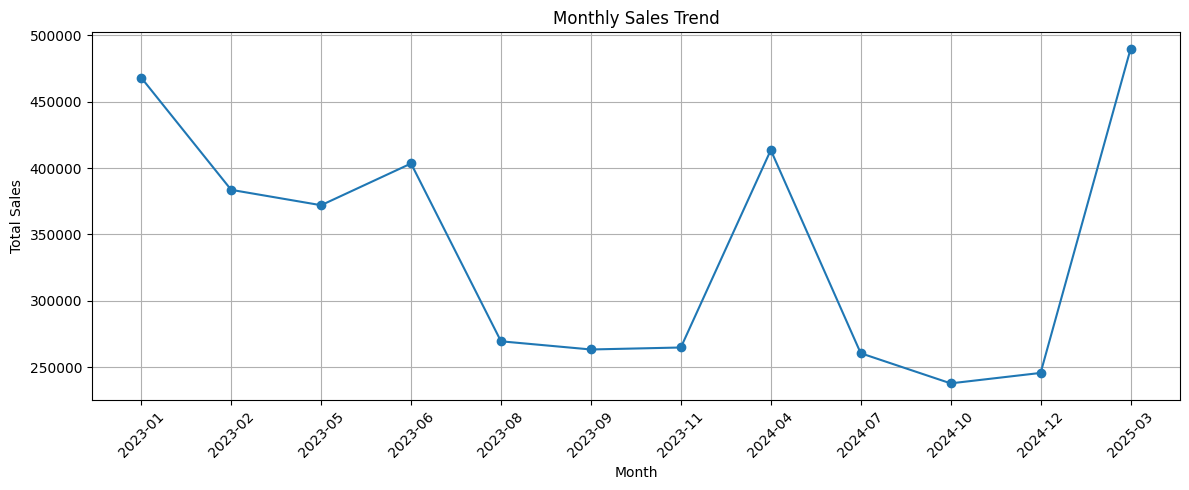

In [ ]:
import matplotlib.pyplot as plt

query = """
SELECT
    strftime('%Y-%m', OrderDate) AS Month,
    ROUND(SUM(NetSales), 2) AS Total_Sales
FROM sales
GROUP BY Month
ORDER BY Month;
"""

monthly_sales = pd.read_sql_query(query, conn)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_sales['Month'],
    monthly_sales['Total_Sales'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

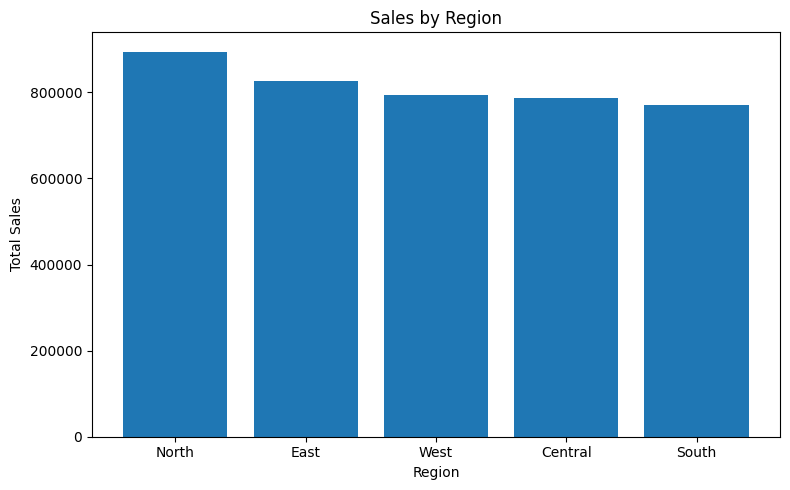

In [ ]:
query = """
SELECT
    Region,
    ROUND(SUM(NetSales), 2) AS Total_Sales
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC;
"""

region_chart = pd.read_sql_query(query, conn)

plt.figure(figsize=(8, 5))

plt.bar(
    region_chart['Region'],
    region_chart['Total_Sales']
)

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

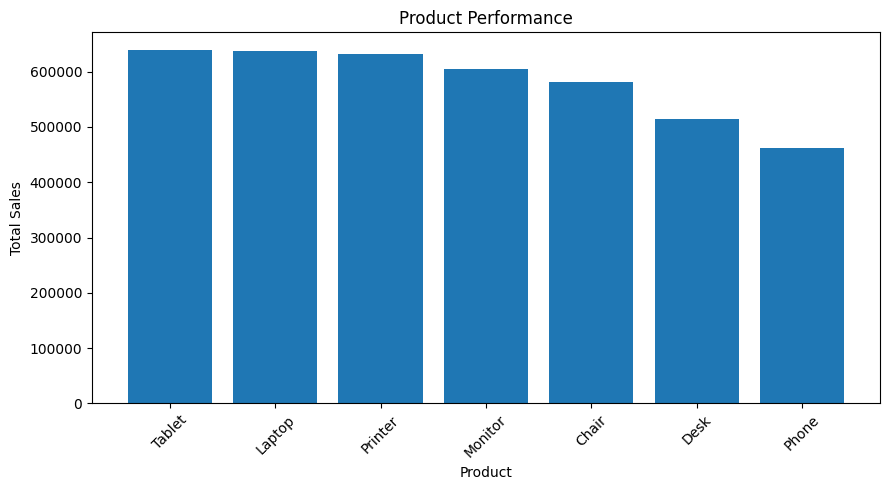

In [ ]:
query = """
SELECT
    Product,
    ROUND(SUM(NetSales), 2) AS Total_Sales
FROM sales
GROUP BY Product
ORDER BY Total_Sales DESC;
"""

product_chart = pd.read_sql_query(query, conn)

plt.figure(figsize=(9, 5))

plt.bar(
    product_chart['Product'],
    product_chart['Total_Sales']
)

plt.title('Product Performance')
plt.xlabel('Product')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

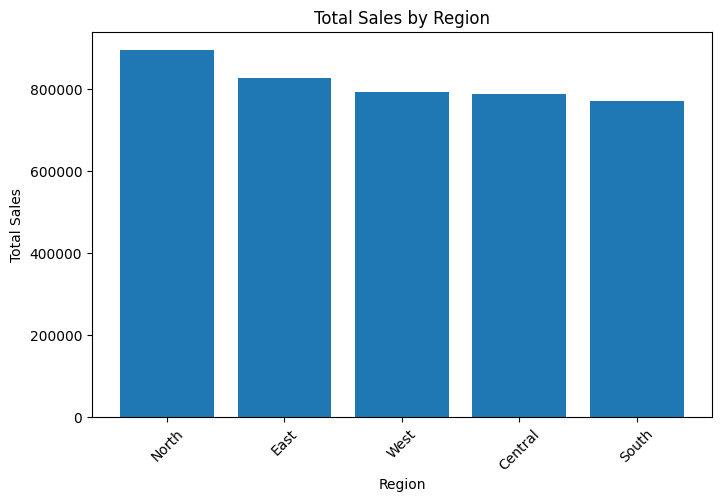

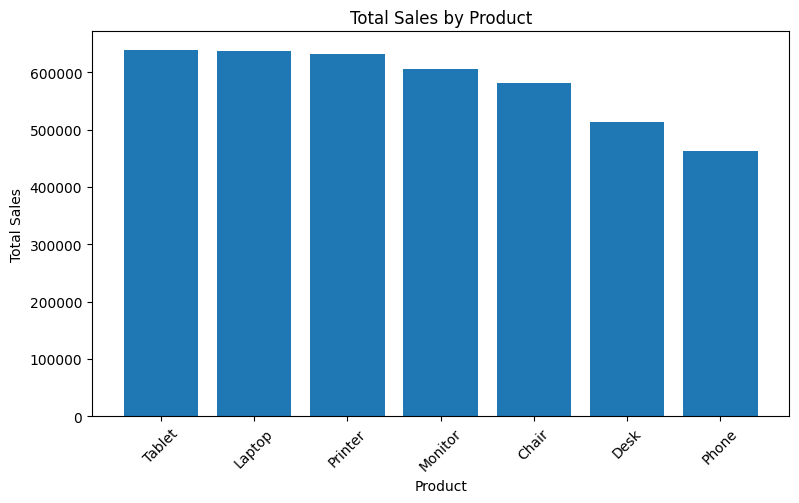

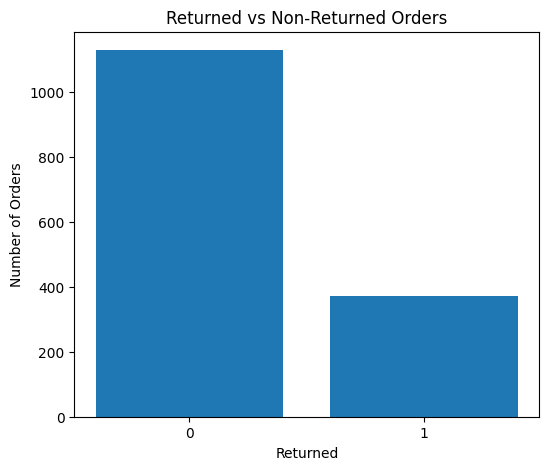

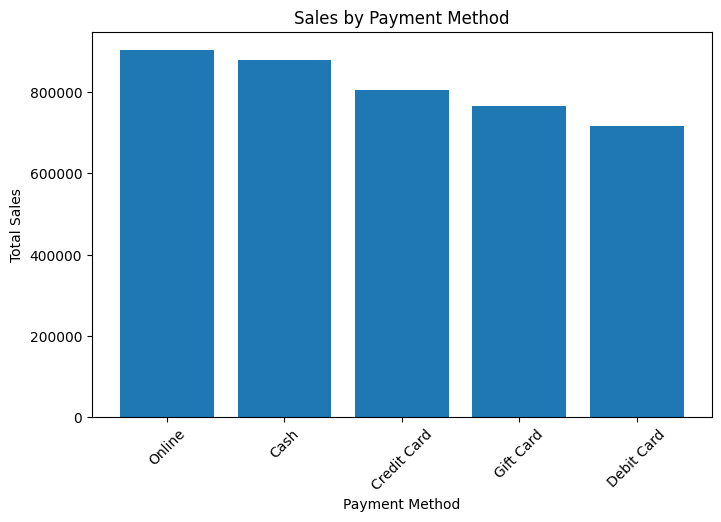

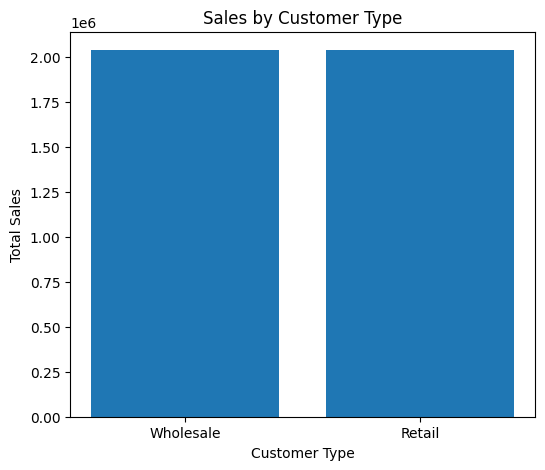

In [ ]:
import matplotlib.pyplot as plt

# 1. Sales by Region
plt.figure(figsize=(8,5))
plt.bar(region_sales["Region"], region_sales["Total_Sales"])
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


# 2. Sales by Product
plt.figure(figsize=(9,5))
plt.bar(product_sales["Product"], product_sales["Total_Sales"])
plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


# 3. Returned vs Non-Returned Orders
plt.figure(figsize=(6,5))
plt.bar(
    return_analysis["Returned"].astype(str),
    return_analysis["Orders"]
)
plt.title("Returned vs Non-Returned Orders")
plt.xlabel("Returned")
plt.ylabel("Number of Orders")
plt.show()


# 4. Sales by Payment Method
plt.figure(figsize=(8,5))
plt.bar(
    payment_analysis["PaymentMethod"],
    payment_analysis["Total_Sales"]
)
plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


# 5. Sales by Customer Type
plt.figure(figsize=(6,5))
plt.bar(
    customer_type_analysis["CustomerType"],
    customer_type_analysis["Total_Sales"]
)
plt.title("Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")
plt.show()

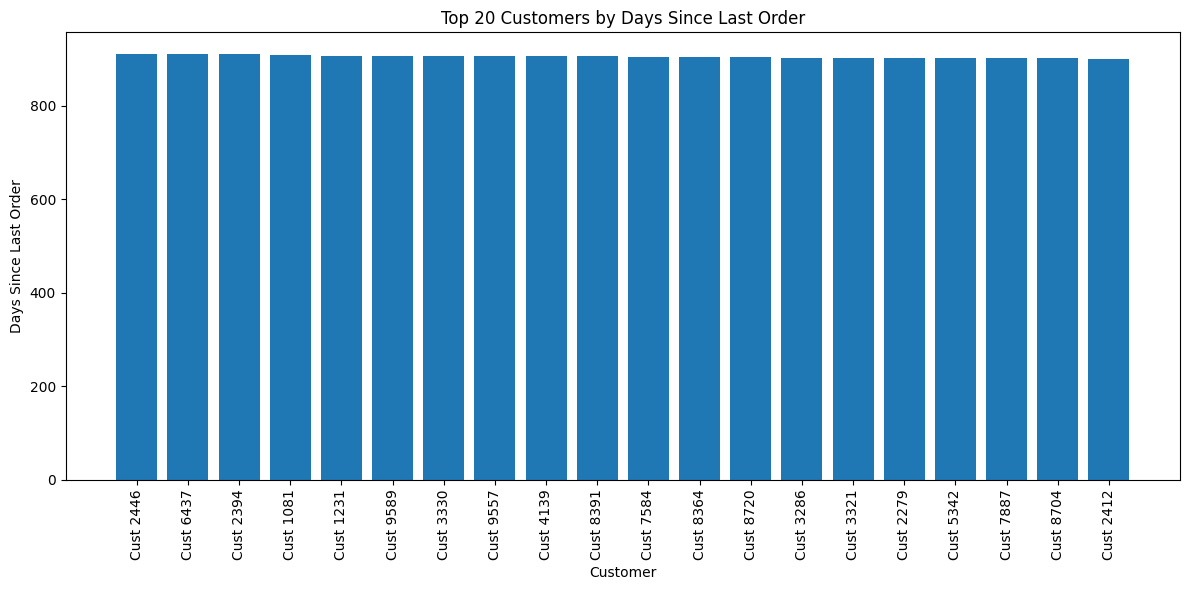

In [ ]:
import matplotlib.pyplot as plt

# Top 20 customers by days since last order
top_churn = churn_analysis.head(20)

plt.figure(figsize=(12, 6))
plt.bar(top_churn["CustomerName"], top_churn["Days_Since_Last_Order"])

plt.title("Top 20 Customers by Days Since Last Order")
plt.xlabel("Customer")
plt.ylabel("Days Since Last Order")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Create churn risk categories
churn_analysis["Churn_Risk"] = pd.cut(
    churn_analysis["Days_Since_Last_Order"],
    bins=[-1, 30, 90, float("inf")],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Count customers in each category
churn_risk_summary = churn_analysis["Churn_Risk"].value_counts()

print(churn_risk_summary)

Churn_Risk
High Risk      1221
Medium Risk     101
Low Risk         49
Name: count, dtype: int64


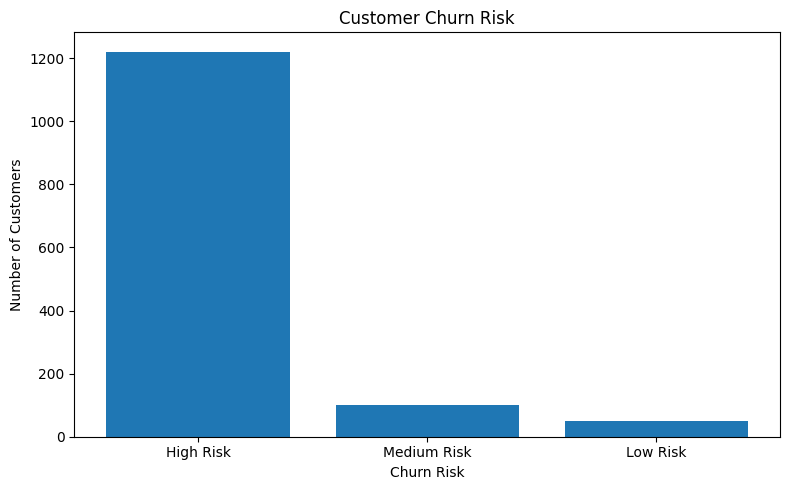

In [ ]:
import matplotlib.pyplot as plt

# Count customers by churn risk
risk_counts = churn_analysis["Churn_Risk"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(risk_counts.index, risk_counts.values)

plt.title("Customer Churn Risk")
plt.xlabel("Churn Risk")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [ ]:
risk_counts

,count
Churn_Risk,
High Risk,1221
Medium Risk,101
Low Risk,49
